## ***MapReduce***

### ***Install & Imports***

In [1]:
!pip install mrjob azure-storage-blob -q

In [2]:
import json
import os
import statistics
from io import StringIO
from pathlib import Path
from kaggle_secrets import UserSecretsClient
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from mrjob.job import MRJob
from mrjob.step import MRStep

### ***Config***

In [3]:
secrets = UserSecretsClient()
os.environ["AZURE_STORAGE_CONN_STR"] = secrets.get_secret("AZURE_STORAGE_CONN_STR")
os.environ["AZURE_CONTAINER"] = secrets.get_secret("AZURE_CONTAINER")

In [4]:
OUTPUT_DIR = Path("/kaggle/working/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs("/kaggle/working/mr_jobs", exist_ok=True)

### ***Load Data from Azure Blob***

In [5]:
def load_from_azure(filename: str):
    """Download a JSON file from Azure Blob Storage."""
    from azure.storage.blob import BlobServiceClient
    conn_str  = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    return json.loads(container.download_blob(f"notebook_data/{filename}").readall())

In [6]:
def save_to_azure(data, filename: str) -> None:
    """Upload a JSON file to Azure Blob Storage for the next notebook to read."""
    from azure.storage.blob import BlobServiceClient
    conn_str  = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    container.upload_blob(name=f"notebook_data/{filename}", data=json.dumps(data), overwrite=True)
    print(f"[Azure] Saved → notebook_data/{filename}")

In [7]:
print("Loading raw_stream.json from Azure Blob")
raw_stream = load_from_azure("raw_stream.json")
print(f"Loaded {len(raw_stream):,} records")
print(f"Symbols: {sorted(set(r['symbol'] for r in raw_stream))[:5]}...")
print(f"Date range: {raw_stream[0]['timestamp'][:10]} → {raw_stream[-1]['timestamp'][:10]}")

# Also save locally for this session
with open(OUTPUT_DIR / "raw_stream.json", "w") as f:
    json.dump(raw_stream, f)

Loading raw_stream.json from Azure Blob
Loaded 32,050 records
Symbols: ['AAVEUSD', 'ADAUSD', 'ALGOUSD', 'ATOMUSD', 'AVAXUSD']...
Date range: 2026-02-24 → 2026-02-26


### ***MapReduce using mrjob***

In [12]:
# Write Job A to file
with open("/kaggle/working/mr_jobs/symbol_aggregator.py", "w") as f:
    f.write("""
from mrjob.job import MRJob, MRStep
import json, math, statistics

class SymbolAggregatorMR(MRJob):
    def steps(self):
        return [MRStep(mapper=self.mapper, reducer=self.reducer)]
    def mapper(self, _, line):
        try:
            r = json.loads(line)
            yield r["symbol"], {
                "open":          float(r.get("open", 0)),
                "high":          float(r.get("high", 0)),
                "low":           float(r.get("low", 0)),
                "close":         float(r.get("close", 0)),
                "volume":        float(r.get("volume", 0)),
                "quote_volume":  float(r.get("quote_volume", 0)),
                "trade_count":   int(r.get("trade_count", 0)),
                "price_chg_pct": float(r.get("price_change_pct_24h", 0)),
            }
        except (KeyError, ValueError, json.JSONDecodeError):
            pass
    def reducer(self, symbol, values):
        vals = list(values)
        n = len(vals)
        if n == 0:
            return
        closes     = [v["close"]        for v in vals]
        highs      = [v["high"]         for v in vals]
        lows       = [v["low"]          for v in vals]
        volumes    = [v["volume"]       for v in vals]
        trade_cnts = [v["trade_count"]  for v in vals]
        chg_pcts   = [v["price_chg_pct"] for v in vals]
        vol_proxy  = statistics.stdev(closes) / (sum(closes) / n) if n > 1 else 0
        yield symbol, {
            "candle_count":      n,
            "avg_close":         round(sum(closes) / n, 6),
            "min_close":         round(min(closes), 6),
            "max_close":         round(max(closes), 6),
            "price_range_pct":   round((max(closes) - min(closes)) / min(closes) * 100, 4) if min(closes) > 0 else 0,
            "volatility_proxy":  round(vol_proxy, 6),
            "total_volume":      round(sum(volumes), 2),
            "avg_volume":        round(sum(volumes) / n, 2),
            "total_trades":      sum(trade_cnts),
            "avg_price_chg_pct": round(sum(chg_pcts) / n, 4),
            "all_time_high":     round(max(highs), 6),
            "all_time_low":      round(min(lows), 6),
        }

if __name__ == "__main__":
    SymbolAggregatorMR.run()
""")

In [13]:
# Write Job B to file
with open("/kaggle/working/mr_jobs/hourly_market.py", "w") as f:
    f.write("""
from mrjob.job import MRJob, MRStep
import json

class HourlyMarketMR(MRJob):
    def steps(self):
        return [MRStep(mapper=self.mapper, reducer=self.reducer)]
    def mapper(self, _, line):
        try:
            r  = json.loads(line)
            ts = r["timestamp"][:13]
            yield ts, {
                "symbol": r["symbol"],
                "close":  float(r.get("close", 0)),
                "open":   float(r.get("open", 0)),
                "volume": float(r.get("volume", 0)),
            }
        except (KeyError, ValueError, json.JSONDecodeError):
            pass
    def reducer(self, hour, values):
        vals    = list(values)
        n       = len(vals)
        volumes = [v["volume"] for v in vals]
        changes = [(v["close"] - v["open"]) / v["open"] * 100 if v["open"] > 0 else 0 for v in vals]
        n_up    = sum(1 for c in changes if c > 0)
        yield hour, {
            "hour":           hour,
            "coins_active":   n,
            "total_volume":   round(sum(volumes), 2),
            "avg_pct_change": round(sum(changes) / n, 4) if n > 0 else 0,
            "breadth_pct_up": round(n_up / n * 100, 1) if n > 0 else 0,
            "max_gain":       round(max(changes), 4) if changes else 0,
            "max_loss":       round(min(changes), 4) if changes else 0,
        }

if __name__ == "__main__":
    HourlyMarketMR.run()
""")

### ***MapReduce jobs execution***

In [14]:
def run_mr_job(job_file, records):
    import sys, subprocess, json
    
    input_file = "/kaggle/working/mr_jobs/input.json"
    with open(input_file, "w") as f:
        f.write("\n".join(json.dumps(r) for r in records))
    
    result = subprocess.run(
        [sys.executable, job_file, input_file],
        capture_output=True, text=True
    )
    
    output = []
    for line in result.stdout.strip().split("\n"):
        if line:
            key, value = line.split("\t")
            output.append({"_key": json.loads(key), **json.loads(value)})
    return output

In [16]:
print("Running Job A: Per-Symbol Aggregation...")
symbol_stats = run_mr_job("/kaggle/working/mr_jobs/symbol_aggregator.py", raw_stream)
symbol_df    = pd.DataFrame(symbol_stats).rename(columns={"_key": "symbol"}).sort_values("total_volume", ascending=False)
print(f"{len(symbol_stats)} symbols")
print(symbol_df[["symbol","avg_close","total_volume","volatility_proxy"]].head())

Running Job A: Per-Symbol Aggregation...
20 symbols
     symbol  avg_close  total_volume  volatility_proxy
16  DOGEUSD   0.098295  4.514189e+09          0.046472
13   XRPUSD   1.416738  1.165392e+09          0.028477
10   ADAUSD   0.285024  1.161018e+09          0.054762
12   XLMUSD   0.159738  3.120081e+08          0.035584
17   DOTUSD   1.480076  1.987316e+08          0.108670


In [17]:
print("Running Job B: Hourly Market Aggregation...")
hourly_stats = run_mr_job("/kaggle/working/mr_jobs/hourly_market.py", raw_stream)
hourly_df    = pd.DataFrame(hourly_stats).rename(columns={"_key": "hour_bucket"}).sort_values("hour_bucket")
print(f"{len(hourly_stats)} hourly buckets")
print(hourly_df[["hour_bucket","coins_active","total_volume","avg_pct_change","breadth_pct_up"]].head(5))

Running Job B: Hourly Market Aggregation...
50 hourly buckets
      hour_bucket  coins_active  total_volume  avg_pct_change  breadth_pct_up
12  2026-02-24T04            20    4937166.72         -0.2751            15.0
13  2026-02-24T05            20    3786456.48         -0.3703             5.0
14  2026-02-24T06            20    1962645.41         -0.1693            15.0
15  2026-02-24T07            20    1682560.74          0.2196            85.0
16  2026-02-24T08            20    3342238.38          0.4216            95.0


### ***Visualizations***

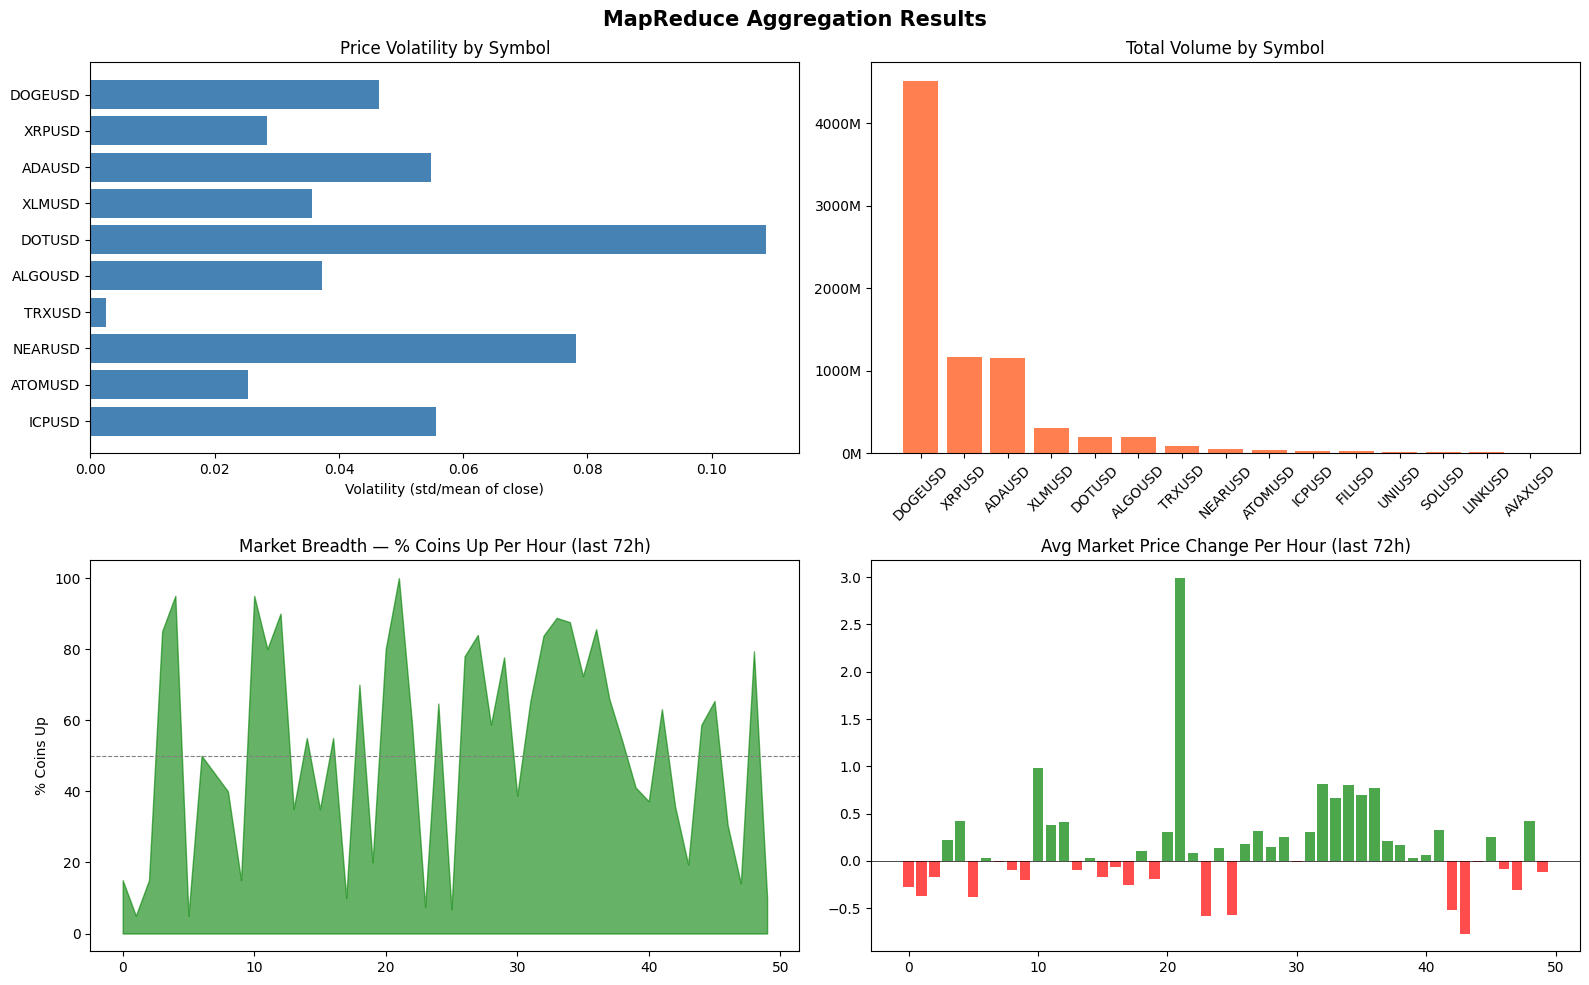

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("MapReduce Aggregation Results", fontsize=15, fontweight="bold")

ax = axes[0, 0]
ax.barh(symbol_df["symbol"].head(10), symbol_df["volatility_proxy"].head(10), color="steelblue")
ax.set_title("Price Volatility by Symbol")
ax.set_xlabel("Volatility (std/mean of close)")
ax.invert_yaxis()

ax = axes[0, 1]
ax.bar(symbol_df["symbol"].head(15), symbol_df["total_volume"].head(15), color="coral")
ax.set_title("Total Volume by Symbol")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

hourly_plot = hourly_df.tail(72)
ax = axes[1, 0]
ax.fill_between(range(len(hourly_plot)), hourly_plot["breadth_pct_up"], alpha=0.6, color="green")
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Market Breadth — % Coins Up Per Hour (last 72h)")
ax.set_ylabel("% Coins Up")

ax = axes[1, 1]
colors = ["green" if x >= 0 else "red" for x in hourly_plot["avg_pct_change"]]
ax.bar(range(len(hourly_plot)), hourly_plot["avg_pct_change"], color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Avg Market Price Change Per Hour (last 72h)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mapreduce_charts.png", dpi=150, bbox_inches="tight")
plt.show()

### ***Save Outputs to Azure Blob***

In [19]:
print("Saving outputs to Azure Blob...")
save_to_azure(symbol_stats, "mr_symbol_stats.json")
save_to_azure(hourly_stats, "mr_hourly_stats.json")

with open(OUTPUT_DIR / "mr_symbol_stats.json", "w") as f:
    json.dump(symbol_stats, f, indent=2)
with open(OUTPUT_DIR / "mr_hourly_stats.json", "w") as f:
    json.dump(hourly_stats, f, indent=2)

Saving outputs to Azure Blob...
[Azure] Saved → notebook_data/mr_symbol_stats.json
[Azure] Saved → notebook_data/mr_hourly_stats.json
